In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/customer_churn.csv")

In [3]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [6]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [7]:
df['Onboard_date'].head()

0    2013-08-30 07:00:40
1    2013-08-13 00:38:46
2    2016-06-29 06:20:07
3    2014-04-22 12:43:12
4    2016-01-19 15:31:15
Name: Onboard_date, dtype: str

In [8]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'],format='mixed', dayfirst=True)

In [10]:
df['Onboard_date'].dtype

dtype('<M8[us]')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


In [16]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[df.duplicated()]

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn


In [17]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


In [18]:
df.head()


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [20]:
df['tenure_group'] = pd.cut(
    df['Years'],
    bins=[0,3,6,10],
    labels=['New','Medium','old']
)

In [22]:
df['tenure_group'].value_counts()

tenure_group
Medium    614
old       244
New        42
Name: count, dtype: int64

In [24]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_group
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,old
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,old
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,old
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,Medium


In [26]:
df.groupby('tenure_group')['Churn'].mean()

tenure_group
New       0.071429
Medium    0.140065
old       0.250000
Name: Churn, dtype: float64

Insight:

Customers with longer tenure show a higher churn rate.

Old customers have a churn rate of 25%, compared to 14% for medium-tenure customers and 7% for new customers.

In [27]:
df.groupby('Account_Manager')['Churn'].mean()

Account_Manager
0    0.141328
1    0.193995
Name: Churn, dtype: float64

Insight:

Customers with account managers have a churn rate of 19.4% compared to 14.1% for customers without account managers.

Further investigation is required to determine whether account managers are assigned to higher-risk customers.

In [28]:
df.groupby("Num_Sites")["Churn"].mean().sort_values(ascending=False)

Num_Sites
13.0    1.000000
12.0    0.843750
14.0    0.833333
11.0    0.554217
10.0    0.259542
9.0     0.102151
8.0     0.037559
6.0     0.014925
7.0     0.013699
5.0     0.000000
3.0     0.000000
4.0     0.000000
Name: Churn, dtype: float64

Insight:

Customers with a higher number of sites are significantly more likely to churn.

Customers with 11+ sites show churn rates above 50%, while customers with fewer than 8 sites rarely churn.

Num_Sites appears to be a strong predictor of customer churn.

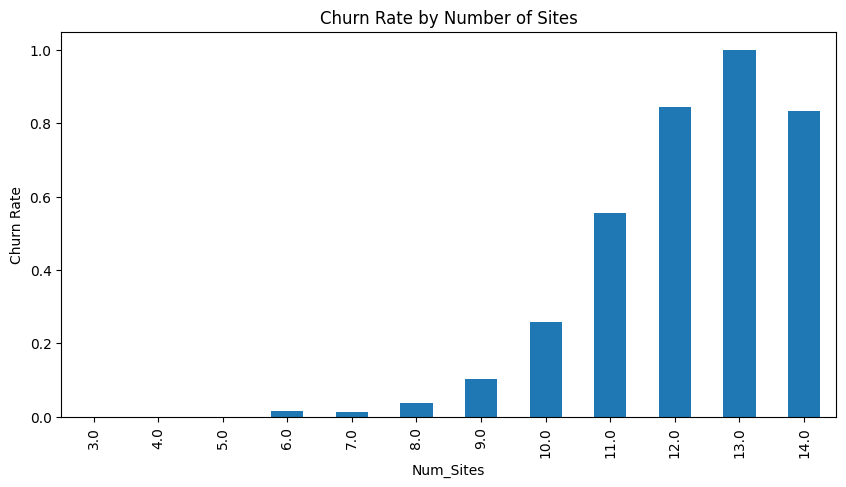

In [29]:
churn_by_sites = df.groupby("Num_Sites")["Churn"].mean()

plt.figure(figsize=(10,5))

churn_by_sites.plot(kind="bar")

plt.title("Churn Rate by Number of Sites")
plt.ylabel("Churn Rate")

plt.show()